In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Load the data
df = pd.read_csv('data/processed/clean_data.csv')

# 2. Add the missing VADER columns right here so Step 5 can see them later
sia = SentimentIntensityAnalyzer()
def vader_predict(text):
    score = sia.polarity_scores(str(text))['compound']
    return 1 if score >= 0.05 else 0

df['vader_pred'] = df['clean_text'].apply(vader_predict)

# 3. Perform your original train/test split code
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {len(X_train)} samples')
print(f'Testing: {len(X_test)} samples')

Training: 80000 samples
Testing: 20000 samples


In [2]:
#STEP 2: Build the TF-IDF vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,    # use top 50,000 words
    ngram_range=(1, 2),    # use single words AND two-word phrases
    min_df=2,              # ignore words that appear in fewer than 2 docs
    max_df=0.95,           # ignore words in more than 95% of docs
    sublinear_tf=True      # apply log normalization
)

# Fit on training data only - never on test data (data leakage!)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print('Vectorizer shape:', X_train_vec.shape)

Vectorizer shape: (80000, 50000)


In [3]:
#STEP 3: Train Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=1.0,           # regularization strength
    max_iter=1000,   # allow enough iterations to converge
    solver='lbfgs',  # efficient solver for large datasets
    n_jobs=-1        # use all CPU cores
)

model.fit(X_train_vec, y_train)
print('Model trained!')


c:\Users\Lenovo\OneDrive\Desktop\Brand Sentiment Analyzer\eshal\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model trained!


In [4]:
#STEP 4: Evaluate the model

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred,
                            target_names=['Negative', 'Positive']))

Accuracy: 0.77225
ROC-AUC: 0.8545000500000001

              precision    recall  f1-score   support

    Negative       0.78      0.75      0.77     10000
    Positive       0.76      0.79      0.78     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



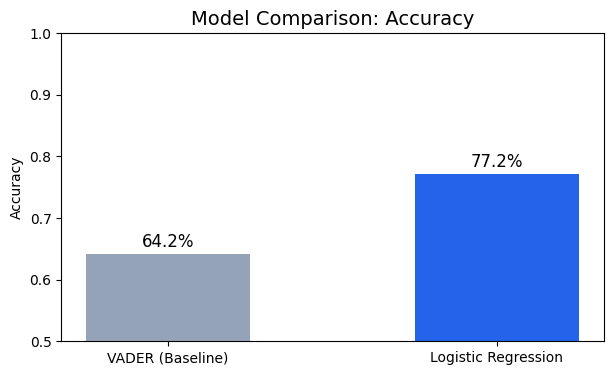

In [5]:
#STEP 5: Compare VADER vs ML Model

import matplotlib.pyplot as plt
import numpy as np

vader_acc = accuracy_score(df['sentiment'], df['vader_pred'])
ml_acc    = accuracy_score(y_test, y_pred)

plt.figure(figsize=(7, 4))
bars = plt.bar(['VADER (Baseline)', 'Logistic Regression'], [vader_acc, ml_acc],
               color=['#94A3B8', '#2563EB'], width=0.5)

plt.ylim(0.5, 1.0)

for bar, acc in zip(bars, [vader_acc, ml_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=12)

plt.title('Model Comparison: Accuracy', fontsize=14)
plt.ylabel('Accuracy')
plt.savefig('reports/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
#STEP 6: Save the trained model

import os
import pickle

# This automatically finds your 'Brand Sentiment Analyzer' main folder path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()

# Build direct, bulletproof file locations
tfidf_path = os.path.join(BASE_DIR, 'models', 'tfidf_vectorizer.pkl')
model_path = os.path.join(BASE_DIR, 'models', 'sentiment_model.pkl')

# Save the files safely
with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf, f)

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Success! Saved perfectly to: {os.path.join(BASE_DIR, 'models')}")

Success! Saved perfectly to: c:\Users\Lenovo\OneDrive\Desktop\Brand Sentiment Analyzer\models


In [7]:
#STEP 7: Check the most informative words

feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

# Link words with their mathematical coefficients (importance scores)
top_pos = [(feature_names[i], coef[i]) for i in coef.argsort()[-20:][::-1]]
top_neg = [(feature_names[i], coef[i]) for i in coef.argsort()[:20]]

print('Top POSITIVE words:')
for word, score in top_pos:
    print(f'{word:<20} {score:.3f}')

print('\nTop NEGATIVE words:')
for word, score in top_neg:
    print(f'{word:<20} {score:.3f}')

Top POSITIVE words:
cant wait            7.352
thanks               5.178
thank                5.114
glad                 4.367
awesome              4.108
love                 4.014
welcome              3.894
congrats             3.768
smile                3.718
great                3.468
yay                  3.449
wish luck            3.420
cool                 3.389
nice                 3.370
loving               3.344
amazing              3.308
happy                3.294
hey                  3.206
enjoy                3.100
sweet                3.053

Top NEGATIVE words:
sad                  -9.804
miss                 -7.161
sick                 -6.298
cant                 -6.109
poor                 -5.992
hate                 -5.942
wish                 -5.860
sucks                -5.409
bad                  -4.979
ugh                  -4.936
hurts                -4.935
sadly                -4.779
missing              -4.768
disappointed         -4.743
didnt                -4.730

In [8]:
import os
print("This notebook file is saved at:")
print(os.path.abspath("04_model.ipynb"))

This notebook file is saved at:
c:\Users\Lenovo\OneDrive\Desktop\Brand Sentiment Analyzer\04_model.ipynb
